# Option Pricing, Delta and Gamma Hedging: Strategy, Testing, and P&L

An option seller doesn't just price an option once and walk away, they carry the risk of the underlying moving against them until expiry, and manage that risk by dynamically trading the underlying (and sometimes other options) to stay hedged. This notebook builds the full pipeline: price a European option with Black-Scholes, replicate it with a discrete-time **delta hedge**, extend to a **delta-gamma hedge** using a second option, then stress-test both strategies across rebalancing frequency and volatility misspecification, and measure the resulting hedging P&L properly.

1. Option pricing and the Greeks (Black-Scholes)
2. Simulating the underlying and the mechanics of a discrete-time delta hedge
3. Delta-gamma hedging with a second option
4. Testing: rebalancing frequency and volatility misspecification
5. Performance measurement: P&L distributions, hedge effectiveness, tail risk

## 1. Option Pricing and the Greeks

The Black-Scholes price of a European call, and the sensitivities ("Greeks") that describe how that price moves:

$$C = S\,N(d_1) - K e^{-rT} N(d_2), \qquad d_1 = \frac{\ln(S/K) + (r + \tfrac12\sigma^2)T}{\sigma\sqrt T}, \qquad d_2 = d_1 - \sigma\sqrt T$$

- **Delta** ($\partial C/\partial S = N(d_1)$): how much the option's value changes per \$1 move in the stock, and the number of shares needed to hedge it away.
- **Gamma** ($\partial^2 C/\partial S^2$): how fast delta itself changes as the stock moves, the risk a delta hedge alone leaves uncovered.
- **Vega** ($\partial C/\partial\sigma$): sensitivity to volatility, the channel through which a *wrong* volatility assumption feeds into hedging P&L, explored in Section 4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

def bs_price_greeks(S, K, T, r, sigma, option_type='call'):
    T = np.maximum(T, 1e-8)   # avoid division by zero exactly at expiry
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
        delta = norm.cdf(d1)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
    gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
    vega = S*norm.pdf(d1)*np.sqrt(T)
    return dict(price=price, delta=delta, gamma=gamma, vega=vega)

S0, K, T, r, sigma = 100, 100, 0.25, 0.03, 0.20
g = bs_price_greeks(S0, K, T, r, sigma, 'call')
print(f"3-month ATM call: price={g['price']:.4f}  delta={g['delta']:.4f}  gamma={g['gamma']:.4f}  vega={g['vega']:.4f}")

3-month ATM call: price=4.3576  delta=0.5497  gamma=0.0396  vega=19.7919


**Diagram - delta and gamma across strikes.** Delta rises smoothly from 0 (deep OTM) to 1 (deep ITM); gamma peaks exactly at-the-money, precisely where a delta hedge needs the most frequent attention.

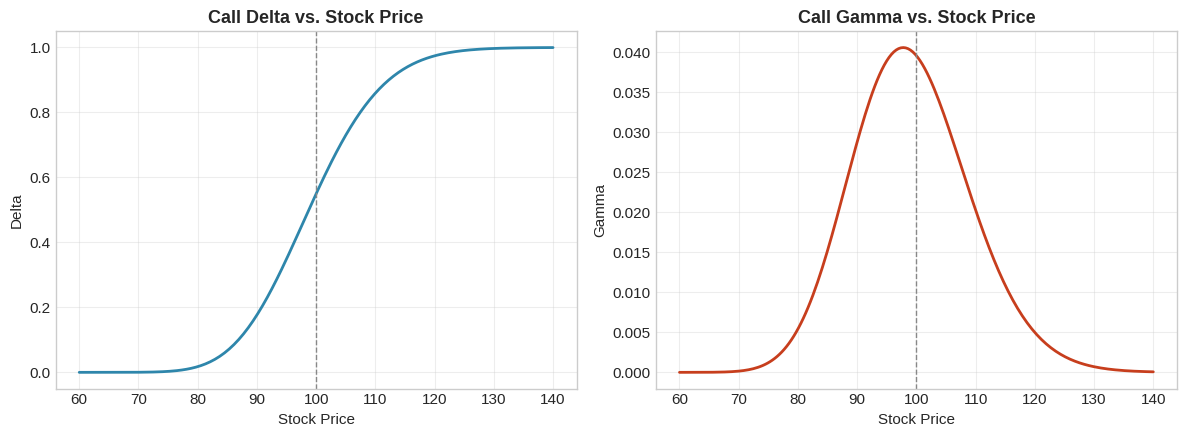

In [2]:
S_range = np.linspace(60, 140, 200)
g_range = bs_price_greeks(S_range, K, T, r, sigma, 'call')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(S_range, g_range['delta'], color='#2E86AB', linewidth=2)
axes[0].axvline(K, color='#888888', linestyle='--', linewidth=1)
axes[0].set_xlabel('Stock Price'); axes[0].set_ylabel('Delta')
axes[0].set_title('Call Delta vs. Stock Price')

axes[1].plot(S_range, g_range['gamma'], color='#C73E1D', linewidth=2)
axes[1].axvline(K, color='#888888', linestyle='--', linewidth=1)
axes[1].set_xlabel('Stock Price'); axes[1].set_ylabel('Gamma')
axes[1].set_title('Call Gamma vs. Stock Price')

plt.tight_layout()
plt.show()

## 2. Simulating the Underlying and Delta Hedging

A dealer who **sells** the call receives the premium and is short its payoff at expiry. Delta hedging replicates that payoff by holding $\Delta_t$ shares of stock at every point in time, funded by a self-financing cash account: buy stock using the premium plus any borrowing, and rebalance the stock position as $\Delta_t$ moves, financing every trade out of the cash account, which itself accrues interest at the risk-free rate between rebalances.

$$\text{Portfolio value}_t = \text{Cash}_t + \Delta_t \cdot S_t$$

If hedging were continuous and volatility were known exactly, this portfolio would replicate the option's payoff perfectly and the strategy's P&L would be exactly zero, the entire content of the Black-Scholes argument. In practice, hedging happens at **discrete** intervals, leaving genuine, measurable P&L, explored below.

In [3]:
def simulate_gbm_paths(n_paths, n_steps, S0, mu, sigma, T, seed):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    increments = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_paths = np.cumsum(increments, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), log_paths]))

def delta_hedge_pnl(S_paths, K, T, r, sigma_hedge, n_rebal_steps, option_type='call'):
    # Discrete-time delta hedge of a SHORT option position. Returns final P&L per path
    # (replicating portfolio value at T minus the option's actual payoff).
    n_paths, n_steps_full_p1 = S_paths.shape
    n_steps_full = n_steps_full_p1 - 1
    stride = n_steps_full // n_rebal_steps
    rebal_idx = np.arange(0, n_steps_full + 1, stride)
    dt_rebal = T / n_rebal_steps

    S0 = S_paths[:, 0]
    g0 = bs_price_greeks(S0, K, T, r, sigma_hedge, option_type)
    premium, delta = g0['price'], g0['delta']
    cash = premium - delta * S0
    stock_held = delta.copy()

    for i in range(1, len(rebal_idx)):
        idx = rebal_idx[i]
        tau = T - T * idx / n_steps_full
        S_t = S_paths[:, idx]
        cash = cash * np.exp(r * dt_rebal)

        if tau > 1e-8:
            new_delta = bs_price_greeks(S_t, K, tau, r, sigma_hedge, option_type)['delta']
        else:
            new_delta = (S_t > K).astype(float) if option_type == 'call' else -(S_t < K).astype(float)

        cash = cash - (new_delta - stock_held) * S_t
        stock_held = new_delta

    S_T = S_paths[:, -1]
    payoff = np.maximum(S_T - K, 0) if option_type == 'call' else np.maximum(K - S_T, 0)
    return cash + stock_held * S_T - payoff

S0, K, T, r = 100, 100, 0.25, 0.03
sigma_true = 0.20
n_fine_steps = int(T * 252)   # daily grid
S_paths = simulate_gbm_paths(3000, n_fine_steps, S0, r, sigma_true, T, seed=1)

pnl_daily = delta_hedge_pnl(S_paths, K, T, r, sigma_true, n_rebal_steps=n_fine_steps)
print(f"Daily rebalancing, correct volatility: mean P&L = {pnl_daily.mean():+.4f}  std = {pnl_daily.std():.4f}")
print(f"(Option premium was {bs_price_greeks(S0, K, T, r, sigma_true)['price']:.4f}, "
      f"so hedging error is about {100*pnl_daily.std()/bs_price_greeks(S0,K,T,r,sigma_true)['price']:.1f}% of the premium)")

Daily rebalancing, correct volatility: mean P&L = +0.0113  std = 0.4298
(Option premium was 4.3576, so hedging error is about 9.9% of the premium)


## 3. Delta-Gamma Hedging

Stock alone has zero gamma, no matter how much is held, the delta hedge is exactly right at the instant it's set, but drifts stale as soon as the stock moves, precisely the gap gamma measures. Adding a second, liquid option (a different strike, same maturity) as a hedging instrument gives one more lever, enough to zero out gamma as well as delta:

$$w_{\text{hedge}} = \frac{\Gamma_{\text{target}}}{\Gamma_{\text{hedge}}} \qquad w_{\text{stock}} = \Delta_{\text{target}} - w_{\text{hedge}}\,\Delta_{\text{hedge}}$$

solved fresh at every rebalance, exactly the same self-financing bookkeeping as Section 2, now with a third traded instrument.

In [4]:
def delta_gamma_hedge_pnl(S_paths, K_target, K_hedge, T, r, sigma_hedge, n_rebal_steps, option_type='call'):
    n_paths, n_steps_full_p1 = S_paths.shape
    n_steps_full = n_steps_full_p1 - 1
    stride = n_steps_full // n_rebal_steps
    rebal_idx = np.arange(0, n_steps_full + 1, stride)
    dt_rebal = T / n_rebal_steps

    S0 = S_paths[:, 0]
    g_t0 = bs_price_greeks(S0, K_target, T, r, sigma_hedge, option_type)
    g_h0 = bs_price_greeks(S0, K_hedge, T, r, sigma_hedge, option_type)

    premium = g_t0['price']
    w_hedge = g_t0['gamma'] / g_h0['gamma']
    w_stock = g_t0['delta'] - w_hedge * g_h0['delta']
    cash = premium - w_hedge * g_h0['price'] - w_stock * S0
    stock_held, hedge_held = w_stock.copy(), w_hedge.copy()

    for i in range(1, len(rebal_idx)):
        idx = rebal_idx[i]
        tau = T - T * idx / n_steps_full
        S_t = S_paths[:, idx]
        cash = cash * np.exp(r * dt_rebal)

        if tau > 1e-8:
            g_t = bs_price_greeks(S_t, K_target, tau, r, sigma_hedge, option_type)
            g_h = bs_price_greeks(S_t, K_hedge, tau, r, sigma_hedge, option_type)
            new_w_hedge = g_t['gamma'] / g_h['gamma']
            new_w_stock = g_t['delta'] - new_w_hedge * g_h['delta']
            hedge_price = g_h['price']
        else:
            new_w_hedge = np.zeros(n_paths)
            new_w_stock = (S_t > K_target).astype(float) if option_type == 'call' else -(S_t < K_target).astype(float)
            hedge_price = np.maximum(S_t - K_hedge, 0) if option_type == 'call' else np.maximum(K_hedge - S_t, 0)

        cash = cash - (new_w_hedge - hedge_held) * hedge_price - (new_w_stock - stock_held) * S_t
        hedge_held, stock_held = new_w_hedge, new_w_stock

    S_T = S_paths[:, -1]
    payoff_target = np.maximum(S_T - K_target, 0) if option_type == 'call' else np.maximum(K_target - S_T, 0)
    payoff_hedge = np.maximum(S_T - K_hedge, 0) if option_type == 'call' else np.maximum(K_hedge - S_T, 0)
    return cash + stock_held * S_T + hedge_held * payoff_hedge - payoff_target

K_hedge_instrument = 110   # an OTM call, liquid enough to trade, used purely to hedge gamma

pnl_delta_wk = delta_hedge_pnl(S_paths, K, T, r, sigma_true, n_rebal_steps=13)
pnl_dg_wk = delta_gamma_hedge_pnl(S_paths, K, K_hedge_instrument, T, r, sigma_true, n_rebal_steps=13)

print(f"Weekly rebalancing, delta-only:  mean={pnl_delta_wk.mean():+.4f}  std={pnl_delta_wk.std():.4f}")
print(f"Weekly rebalancing, delta-gamma: mean={pnl_dg_wk.mean():+.4f}  std={pnl_dg_wk.std():.4f}")
print(f"Variance reduction from gamma hedging: {100*(1 - pnl_dg_wk.var()/pnl_delta_wk.var()):.1f}%")

Weekly rebalancing, delta-only:  mean=-0.0387  std=0.8438
Weekly rebalancing, delta-gamma: mean=-0.0387  std=0.6139
Variance reduction from gamma hedging: 47.1%


## 4. Testing: Rebalancing Frequency and Volatility Misspecification

Two things break the "perfect replication" story in practice: hedging only at discrete intervals (not continuously), and hedging with the wrong volatility (the hedge ratios in Sections 2-3 all used `sigma_hedge`, which need not equal the volatility the stock actually realizes).

In [5]:
rebal_grid = [(n_fine_steps, 'Daily (63)'), (13, 'Weekly (13)'), (3, 'Monthly (3)')]
freq_results = []
for n_rebal, label in rebal_grid:
    pnl = delta_hedge_pnl(S_paths, K, T, r, sigma_true, n_rebal_steps=n_rebal)
    freq_results.append((label, pnl))
    print(f"{label:<14}: mean={pnl.mean():+.4f}  std={pnl.std():.4f}")

print()
vol_grid = [(0.15, 'Hedge underestimates vol (15% vs. true 20%)'),
            (0.20, 'Correct vol (20%)'),
            (0.25, 'Hedge overestimates vol (25% vs. true 20%)')]
vol_results = []
for sigma_hedge, label in vol_grid:
    pnl = delta_hedge_pnl(S_paths, K, T, r, sigma_hedge, n_rebal_steps=n_fine_steps)
    vol_results.append((label, pnl))
    print(f"{label:<48}: mean={pnl.mean():+.4f}  std={pnl.std():.4f}")

Daily (63)    : mean=+0.0113  std=0.4298
Weekly (13)   : mean=-0.0387  std=0.8438
Monthly (3)   : mean=+0.0852  std=1.8185

Hedge underestimates vol (15% vs. true 20%)     : mean=-0.9970  std=0.6082
Correct vol (20%)                               : mean=+0.0113  std=0.4298
Hedge overestimates vol (25% vs. true 20%)      : mean=+1.0189  std=0.5437


**Diagram - P&L distributions.** Left: less frequent rebalancing widens the P&L distribution without shifting its center. Right: a volatility misspecification shifts the *center* of the distribution, a systematic bias, not just noise, in the direction implied by charging too little or too much for the risk actually realized.

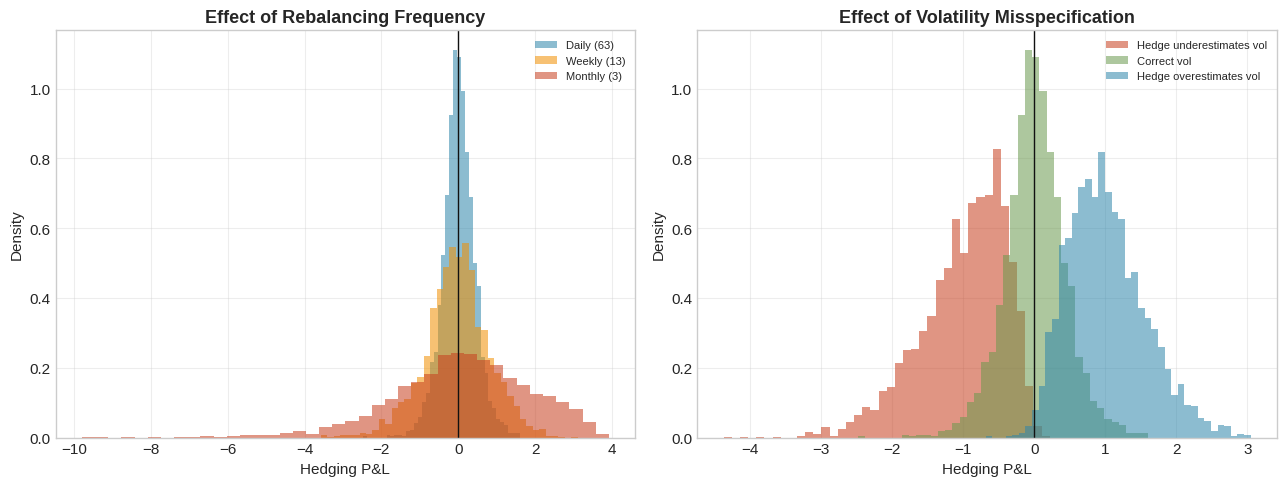

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_freq = ['#2E86AB', '#F18F01', '#C73E1D']
for (label, pnl), c in zip(freq_results, colors_freq):
    axes[0].hist(pnl, bins=40, alpha=0.55, color=c, label=label, density=True)
axes[0].axvline(0, color='#111111', linewidth=1)
axes[0].set_xlabel('Hedging P&L'); axes[0].set_ylabel('Density')
axes[0].set_title('Effect of Rebalancing Frequency')
axes[0].legend(fontsize=8)

colors_vol = ['#C73E1D', '#6A994E', '#2E86AB']
for (label, pnl), c in zip(vol_results, colors_vol):
    axes[1].hist(pnl, bins=40, alpha=0.55, color=c, label=label.split('(')[0].strip(), density=True)
axes[1].axvline(0, color='#111111', linewidth=1)
axes[1].set_xlabel('Hedging P&L'); axes[1].set_ylabel('Density')
axes[1].set_title('Effect of Volatility Misspecification')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Performance Measurement

A proper hedge-performance report needs more than a mean and a standard deviation: hedging effectiveness relative to an unhedged position, and tail risk, both matter to a real risk desk.

In [7]:
def hedge_performance_summary(pnl, label, premium):
    return {
        'Strategy': label,
        'Mean P&L': pnl.mean(),
        'Std P&L': pnl.std(),
        'P&L / Premium (%)': 100 * pnl.std() / premium,
        '5% VaR': np.percentile(pnl, 5),
        '1% VaR': np.percentile(pnl, 1),
        'Worst case': pnl.min(),
    }

premium = bs_price_greeks(S0, K, T, r, sigma_true)['price']
unhedged_pnl = premium - np.maximum(S_paths[:, -1] - K, 0)   # collect premium, hedge nothing at all

rows = [
    hedge_performance_summary(unhedged_pnl, 'Unhedged', premium),
    hedge_performance_summary(delta_hedge_pnl(S_paths, K, T, r, sigma_true, n_rebal_steps=3), 'Delta-only, monthly', premium),
    hedge_performance_summary(delta_hedge_pnl(S_paths, K, T, r, sigma_true, n_rebal_steps=13), 'Delta-only, weekly', premium),
    hedge_performance_summary(delta_hedge_pnl(S_paths, K, T, r, sigma_true, n_rebal_steps=n_fine_steps), 'Delta-only, daily', premium),
    hedge_performance_summary(delta_gamma_hedge_pnl(S_paths, K, K_hedge_instrument, T, r, sigma_true, n_rebal_steps=13), 'Delta-gamma, weekly', premium),
]
import pandas as pd
summary_df = pd.DataFrame(rows).set_index('Strategy')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', None)
print(summary_df.round(4))

                     Mean P&L  Std P&L  P&L / Premium (%)   5% VaR   1% VaR  Worst case
Strategy                                                                               
Unhedged               0.2628   6.2141           142.6037 -13.2379 -20.3490    -58.7972
Delta-only, monthly    0.0852   1.8185            41.7318  -3.0340  -5.3383     -9.7964
Delta-only, weekly    -0.0387   0.8438            19.3648  -1.4946  -2.2335     -3.5729
Delta-only, daily      0.0113   0.4298             9.8633  -0.7002  -1.0760     -2.4777
Delta-gamma, weekly   -0.0387   0.6139            14.0869  -0.8153  -1.6438     -3.1162


**Diagram - hedge effectiveness.** Standard deviation of P&L, as a fraction of the option premium, across every strategy tested: each rung of hedging (no hedge -> monthly delta -> weekly delta -> daily delta -> weekly delta-gamma) cuts risk further.

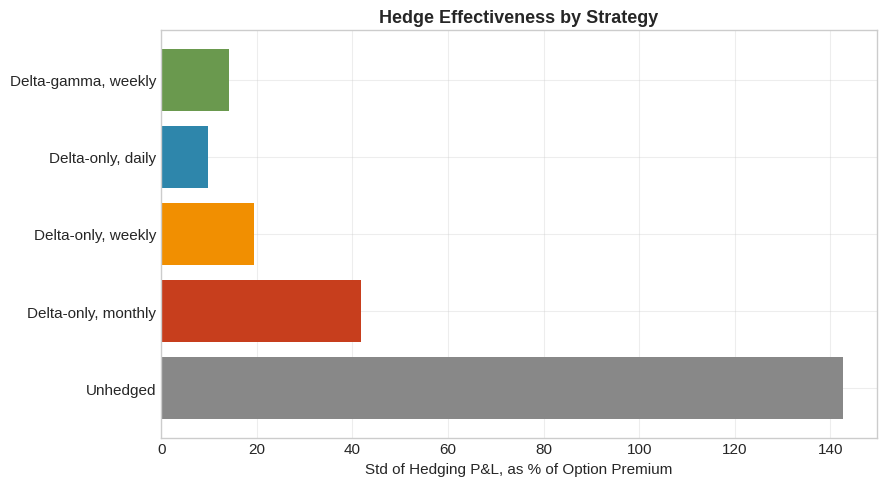

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#888888', '#C73E1D', '#F18F01', '#2E86AB', '#6A994E']
ax.barh(summary_df.index, summary_df['P&L / Premium (%)'], color=colors_bar)
ax.set_xlabel('Std of Hedging P&L, as % of Option Premium')
ax.set_title('Hedge Effectiveness by Strategy')
plt.tight_layout()
plt.show()